## BONUS ANALYSIS: MOVIE RATINGS BY SUBSCRIPTION STATUS

In [1]:
# IMPORT REQUIRED LIBRARIES
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Create database connection

connection = mysql.connector.connect(
    host="localhost",        # change if needed
    user="root",             # your MySQL username
    password="Test12345mysql",# your MySQL password
    database="StreamflixDB"
)

print("Connection successful!")

Connection successful!


In [3]:
# GLOBAL VISUALIZATION SETTINGS

# Consistent theme across all visualizations

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [4]:
# OPTIONAL- ONLY IN MY LAPTOP
import warnings

warnings.filterwarnings(
    'ignore',
    message='pandas only supports SQLAlchemy connectable*'
)

## ANALYSIS 1: Average Rating per Movie (Top 10)

In [5]:
# Step 1: Query Data from MySQL
query_avg_movie = """
SELECT 
    m.Title,
    ROUND(AVG(r.Rating), 2) AS Avg_Rating,
    COUNT(r.RatingID) AS RatingCount
FROM Movies m 
JOIN Ratings r 
    ON r.MovieID = m.MovieID
GROUP BY m.MovieID, m.Title
HAVING COUNT(r.RatingID) >= 8
ORDER BY 
    Avg_Rating DESC,
    RatingCount DESC
LIMIT 10;
"""

df_movie_ratings = pd.read_sql(query_avg_movie, connection)
df_movie_ratings

,Title,Avg_Rating,RatingCount
0,Nights of Cabiria (Le Notti di Cabiria),3.84,8
1,"Thieves (Voleurs, Les)",3.60,9
2,"Ipcress File, The",3.26,8
3,Autumn Heart,3.21,8
4,"Winter Guest, The",3.15,8
5,Sunset Park,2.98,8
6,Days of Thunder,2.95,8
7,"Three Caballeros, The",2.90,8
8,My Name Is Joe,2.88,8
9,Parenthood,2.83,11


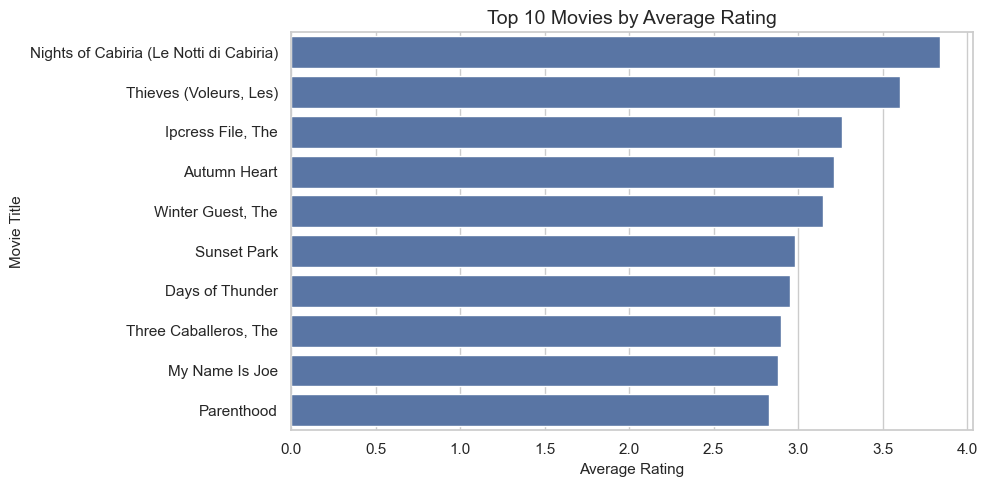

In [6]:
# Step 2. Visualisation
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_movie_ratings,
    x="Avg_Rating",
    y="Title",
   
)

plt.title("Top 10 Movies by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.tight_layout()
plt.show()

## ANALYSIS 2: Ratings by Subscription Type (FREE vs SUBSCRIBER)

In [7]:
# Step 1: Query Data from MySQL
query_sub_rating = """
SELECT 
    u.SubscriptionStatus,
    ROUND(AVG(r.Rating), 2) AS Avg_Rating,
    COUNT(r.RatingID) AS RatingCount
FROM Ratings r
JOIN Users u ON r.UserID = u.UserID
GROUP BY u.SubscriptionStatus;
"""

df_sub_ratings = pd.read_sql(query_sub_rating, connection)
df_sub_ratings

,SubscriptionStatus,Avg_Rating,RatingCount
0,SUBSCRIBER,2.97,4858
1,FREE,2.98,5142


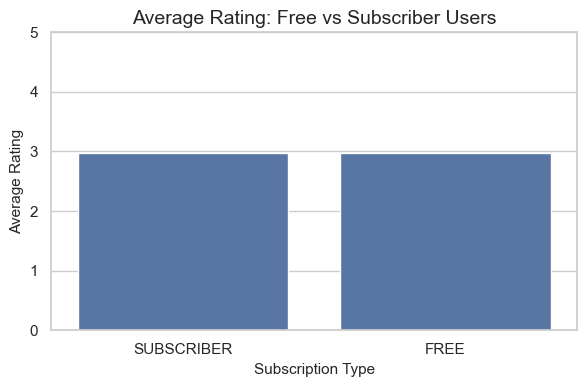

In [8]:
# Step 2. Visualisation
plt.figure(figsize=(6,4))

sns.barplot(
    data=df_sub_ratings,
    x="SubscriptionStatus",
    y="Avg_Rating",

)

plt.title("Average Rating: Free vs Subscriber Users")
plt.xlabel("Subscription Type")
plt.ylabel("Average Rating")
plt.ylim(0,5)
plt.tight_layout()
plt.show()

## ANALYSIS 3:Rating Distribution by Subscription

In [9]:
# Step 1: Query Data from MySQL
query_distribution = """
SELECT 
    u.SubscriptionStatus,
    r.Rating
FROM Ratings r
JOIN Users u ON r.UserID = u.UserID;
"""

df_distribution = pd.read_sql(query_distribution, connection)
df_distribution

,SubscriptionStatus,Rating
0,SUBSCRIBER,4.1
1,FREE,3.1
2,FREE,4.0
3,FREE,2.4
4,FREE,3.1
...,...,...
9995,SUBSCRIBER,1.7
9996,SUBSCRIBER,1.2
9997,FREE,2.7
9998,FREE,3.0


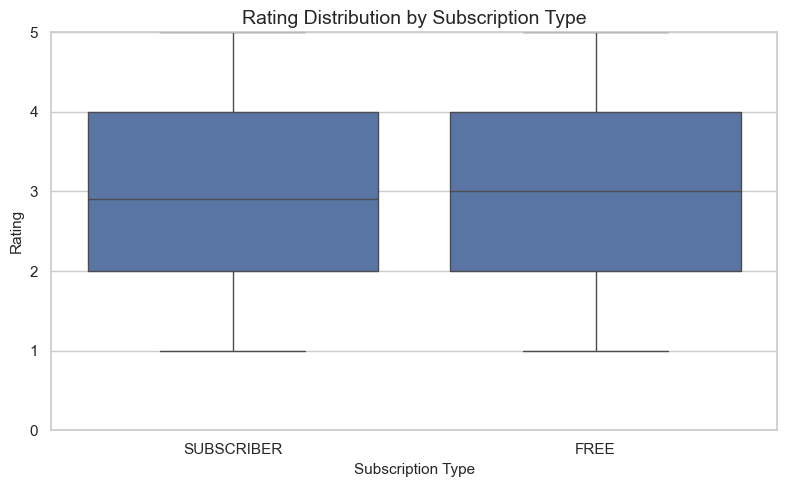

In [10]:
# Step 2. Visualisation
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_distribution,
    x="SubscriptionStatus",
    y="Rating",
)

plt.title("Rating Distribution by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Rating")
plt.ylim(0,5)
plt.tight_layout()
plt.show()